In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kernelcpd import binseg
from joblib import Parallel, delayed
np.random.seed(123)

In [2]:
# Parameters
N = 200
change_point = 110
f1 = 0.05
f2 = 0.08
noise_std = 0.3

# Time index
n = np.arange(N)

# Create frequency array
f = np.zeros(N)
f[:change_point] = f1
f[change_point:] = f2

# Signal + noise
y = np.cos(2 * np.pi * f * n) + np.random.normal(0, noise_std, N)
y = y.reshape(-1, 1)

In [3]:
T_values = range(2, 31, 2)

def run_binseg(T):
    return T, binseg(sequence=y, n_changepoints=1, T=T, laplace_option="h1") + 1

# Run in parallel
results_list = Parallel(n_jobs=-1)(delayed(run_binseg)(T) for T in T_values)

# Convert list of tuples to dictionary
results = dict(results_list)

In [4]:
results

{2: array([6]),
 4: array([195]),
 6: array([110]),
 8: array([110]),
 10: array([109]),
 12: array([110]),
 14: array([110]),
 16: array([111]),
 18: array([111]),
 20: array([111]),
 22: array([111]),
 24: array([110]),
 26: array([116]),
 28: array([115]),
 30: array([115])}

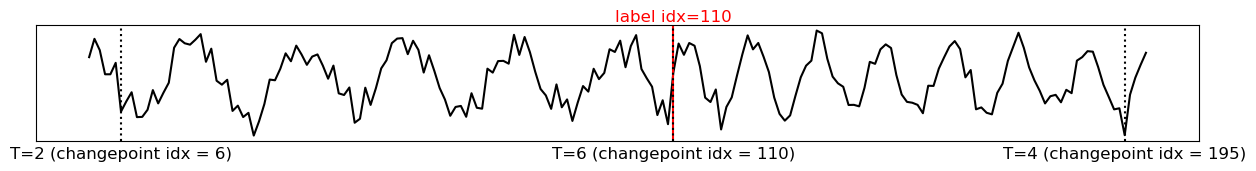

In [5]:
fontsize = 12
plt.figure(figsize=(15, 1.5))
plt.plot(y, color="black")

ax = plt.gca()

# Add vertical line
xline = 110
ax.axvline(xline, color="red")
ax.text(xline, max(y) + 0.2, "label idx=110", color="red", fontsize=fontsize, ha="center", va="bottom")

# Add vertical line
xline = 6
ax.axvline(xline, color="black", linestyle=':')
ax.text(xline, min(y) - 0.8, f"T=2 (changepoint idx = {xline})", color="black", fontsize=fontsize, ha="center", va="bottom")

# Add vertical line
xline = 195
ax.axvline(xline, color="black", linestyle=':')
ax.text(xline, min(y) - 0.8, f"T=4 (changepoint idx = {xline})", color="black", fontsize=fontsize, ha="center", va="bottom")

# Add vertical line
xline = 110
ax.axvline(xline, color="black", linestyle=':')
ax.text(xline, min(y) - 0.8, f"T=6 (changepoint idx = {xline})", color="black", fontsize=fontsize, ha="center", va="bottom")

# Remove tick labels
ax.set_xticks([])
ax.set_yticks([])

# Adjust y-axis tick label size
ax.tick_params(axis='y', labelsize=20)

plt.show()